# Experiment 2: seed sensitivity during training

There are 32 additional trials, not another full grid: four bases, four partitions and two tasks at one predefined reference recipe. Paired seed effects check sensitivity at that recipe; two seeds do not establish robustness of every grid cell.

## 0. Evidence and scope

The availability tables distinguish observed measurements from unavailable outcomes. Missing measurements are not zero effects.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
REPO = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'pyproject.toml').is_file())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
from src.visualize import style, campaign as cp, publication as pub, diagnostics as dg
from src.visualize.figures import FigureSaver
from src.visualize.inputs import source_description
from src.data.dataset_names import display_frame
style.apply()
sink = FigureSaver('experiment2/01_training')
report = cp.NotebookReport('Experiment 2: seed sensitivity during training', sink=sink)

print(source_description())
report.add('0. Evidence and scope', source_description())
from src.visualize import pilots as pv

DATA: no external source selected.
Project: no external source selected.
Missing project records are unavailable evidence, not zero effects or failed training.


## 1. Paired design and coverage

Compare main-seed and additional-seed outcomes only where the same recipe, dataset and milestone are available.

,evidence,records,origin
0,Planned trials,16,Config; not scheduler state
1,Completed trials,0,DATA manifests
2,Epoch rows,0,Project training diagnostics
3,Milestone rows,0,Project trajectory diagnostics
4,Benchmark folds,0,Project final evaluation


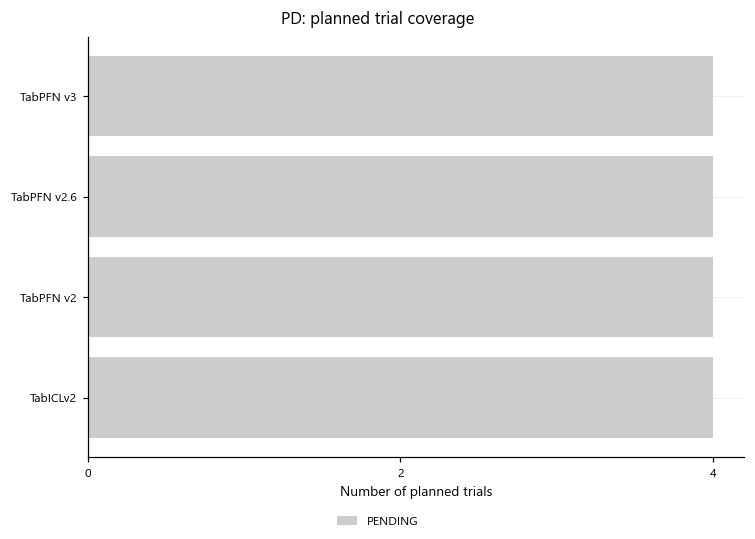

PD. Recorded status of 16 planned PD trials by base model. PENDING denotes no manifest outcome and can include currently running or queued jobs. INTERRUPTED denotes saved progress, not a numerical failure. This figure does not query the scheduler.

,evidence,records,origin
0,Planned trials,16,Config; not scheduler state
1,Completed trials,0,DATA manifests
2,Epoch rows,0,Project training diagnostics
3,Milestone rows,0,Project trajectory diagnostics
4,Benchmark folds,0,Project final evaluation


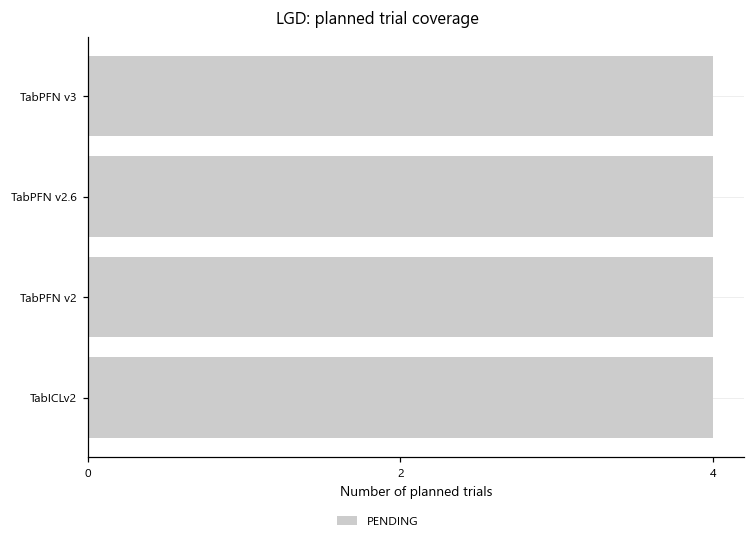

LGD. Recorded status of 16 planned LGD trials by base model. PENDING denotes no manifest outcome and can include currently running or queued jobs. INTERRUPTED denotes saved progress, not a numerical failure. This figure does not query the scheduler.

In [2]:
main = {track: cp.load_campaign(1, track) for track in ('pd','lgd')}
repeat = {track: cp.load_campaign(2, track) for track in ('pd','lgd')}
for run in repeat.values():
    report.table(run.track.upper()+' repeat evidence', pub.availability(run))
    cp.show(sink, cp.plot_coverage(run), track=run.track)
report.add('1. Paired design and coverage', '\n\n'.join(cp.coverage_summary(run) for run in repeat.values()))


## 2. Loss and optimizer dynamics

Loss, gradients, clipping and parameter drift are shown through training at the fixed reference recipe.

No measurements available for this section yet.


""


No measurements available for this section yet.


""


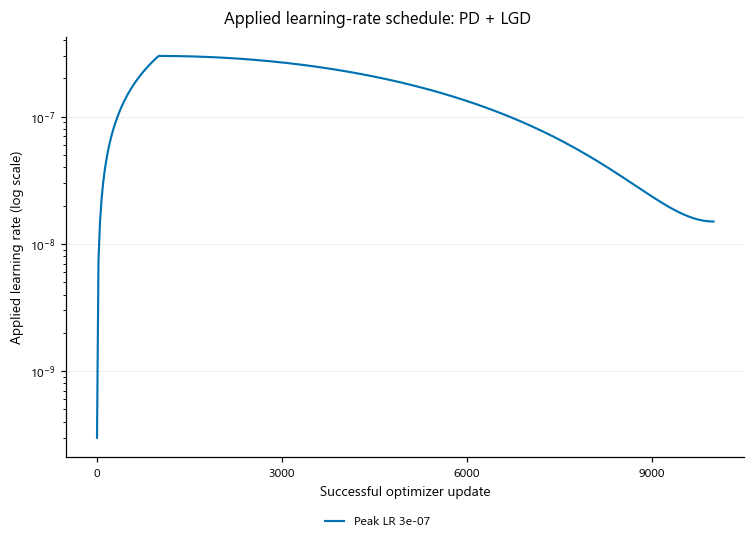

Learning rates evaluated from the recorded campaign configuration using the training scheduler. Each distinct peak-rate schedule is drawn once, pooling tasks only when budget, warmup and decay floor agree. The rate for update u is the scheduler value before that update (index u minus one). The first update has zero learning rate and is omitted from the logarithmic axis, but retained in the table. These are configured schedules; measured epoch-end rates and their sampling intervals are reported separately.

In [3]:
for run in repeat.values():
    cp.show(sink, pv.plot_process_overview(run), track=run.track)
    for label, frame in cp.loss_coverage_tables(run).items():
        report.table(run.track.upper()+' '+label, frame)
cp.show(sink, pv.plot_schedule(list(repeat.values())))
report.add('2. Loss and optimizer dynamics', 'Missing observations remain unavailable; partial table-coverage loss epochs are reported separately. Shared task schedules are drawn once.')

## 3. Sensitivity through training

Gray curves retain dataset heterogeneity; the mean requires matching dataset support at each displayed update.

In [4]:
pairs = {track: cp.seed_pairs(main[track], repeat[track]) for track in ('pd','lgd')}
for track, data in pairs.items():
    cp.show(sink, cp.plot_seed_trajectories(data, main[track].metric, milestones=main[track].cfg.train.trajectory_steps), track=track)
report.add('3. Sensitivity through training', 'Positive differences favor the additional seed; they are not the average benefit of continued pretraining.')


No measurements available for this section yet.
No measurements available for this section yet.


## 4. Resources and parameter movement

Sampled device counters and anchored-tensor movement accompany learning curves.

In [5]:
for run in repeat.values():
    cp.show(sink, dg.plot_resource_curves(run), track=run.track)
    cp.show(sink, dg.plot_parameters(run), track=run.track)
    report.table(run.track.upper()+' training costs', pub.cost_summary(run))
report.add('4. Resources and parameter movement', 'Device-level samples are not integrated energy or billed allocation time.')

No measurements available for this section yet.
No measurements available for this section yet.


""


No measurements available for this section yet.
No measurements available for this section yet.


""


## Complete text summary

Complete numerical values and figure captions, following the section order above.

In [6]:
print(report.summary(sink))

Experiment 2: seed sensitivity during training

0. Evidence and scope
DATA: no external source selected.
Project: no external source selected.
Missing project records are unavailable evidence, not zero effects or failed training.

1. Paired design and coverage
Run cpt_seeds_v5; PD; 16 planned trials; target 10,000 successful updates.
status
PENDING    16
0 trajectory records; 0 benchmark fold records.
PENDING means no recorded outcome; it can include running or queued work. This is not live scheduler state.

Run cpt_seeds_v5; LGD; 16 planned trials; target 10,000 successful updates.
status
PENDING    16
0 trajectory records; 0 benchmark fold records.
PENDING means no recorded outcome; it can include running or queued work. This is not live scheduler state.

Table: PD repeat evidence
           evidence  records                          origin
0    Planned trials       16     Config; not scheduler state
1  Completed trials        0                  DATA manifests
2        Epoch rows    